In [1]:
import pandas as pd

movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

print(movies.head())
print(ratings.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


In [2]:
user_movie_matrix = ratings.pivot(index='userId', columns='movieId', values='rating')

user_movie_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
matrix_filled = user_movie_matrix.fillna(0)

matrix_filled.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
from sklearn.metrics.pairwise import cosine_similarity

user_similarity = cosine_similarity(matrix_filled)

In [6]:
similarity_df = pd.DataFrame(user_similarity,
                             index=user_movie_matrix.index,
                             columns=user_movie_matrix.index)

similarity_df.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
userId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.027283,0.059720,0.194395,0.129080,0.128152,0.158744,0.136968,0.064263,0.016875,...,0.080554,0.164455,0.221486,0.070669,0.153625,0.164191,0.269389,0.291097,0.093572,0.145321
2,0.027283,1.000000,0.000000,0.003726,0.016614,0.025333,0.027585,0.027257,0.000000,0.067445,...,0.202671,0.016866,0.011997,0.000000,0.000000,0.028429,0.012948,0.046211,0.027565,0.102427
3,0.059720,0.000000,1.000000,0.002251,0.005020,0.003936,0.000000,0.004941,0.000000,0.000000,...,0.005048,0.004892,0.024992,0.000000,0.010694,0.012993,0.019247,0.021128,0.000000,0.032119
4,0.194395,0.003726,0.002251,1.000000,0.128659,0.088491,0.115120,0.062969,0.011361,0.031163,...,0.085938,0.128273,0.307973,0.052985,0.084584,0.200395,0.131746,0.149858,0.032198,0.107683
5,0.129080,0.016614,0.005020,0.128659,1.000000,0.300349,0.108342,0.429075,0.000000,0.030611,...,0.068048,0.418747,0.110148,0.258773,0.148758,0.106435,0.152866,0.135535,0.261232,0.060792


In [7]:
def recommend_movies(user_id, num_recommendations=5):

    similar_users = similarity_df[user_id].sort_values(ascending=False)[1:6]

    similar_users_ratings = user_movie_matrix.loc[similar_users.index]

    mean_ratings = similar_users_ratings.mean().sort_values(ascending=False)

    watched_movies = user_movie_matrix.loc[user_id].dropna().index

    recommendations = mean_ratings.drop(watched_movies)

    return recommendations.head(num_recommendations)

In [8]:
def recommend_movie_titles(user_id):

    movie_ids = recommend_movies(user_id).index

    return movies[movies['movieId'].isin(movie_ids)][['title']]

In [9]:
recommend_movie_titles(1)

,title
4604,Ninja Scroll (Jûbei ninpûchô) (1995)
4908,Dawn of the Dead (2004)
4927,Dawn of the Dead (1978)
5260,Spider-Man 2 (2004)
5335,Shaun of the Dead (2004)


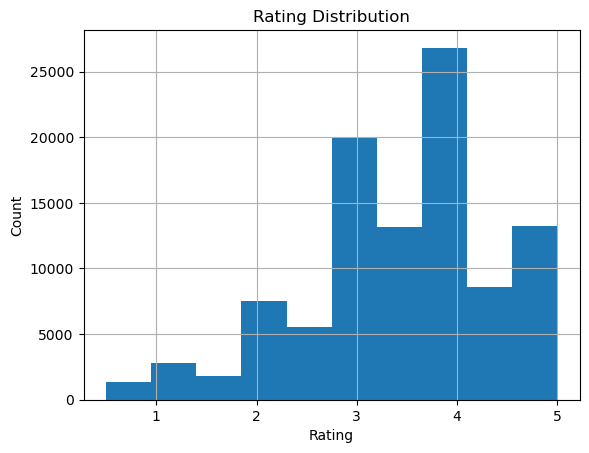

In [10]:
import matplotlib.pyplot as plt

ratings['rating'].hist()
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

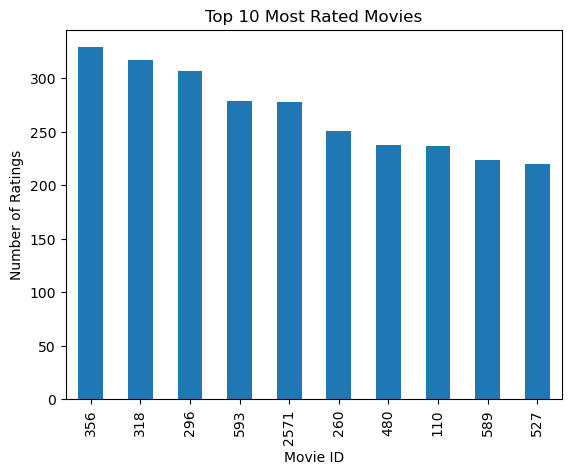

In [11]:
movie_ratings = ratings.groupby('movieId')['rating'].count().sort_values(ascending=False)

top_movies = movie_ratings.head(10)

top_movies.plot(kind='bar')

plt.title("Top 10 Most Rated Movies")
plt.xlabel("Movie ID")
plt.ylabel("Number of Ratings")

plt.show()

In [12]:
total_cells = user_movie_matrix.shape[0] * user_movie_matrix.shape[1]

empty_cells = user_movie_matrix.isna().sum().sum()

sparsity = (empty_cells / total_cells) * 100

print("Sparsity of Utility Matrix:", sparsity, "%")

Sparsity of Utility Matrix: 98.30003169443864 %


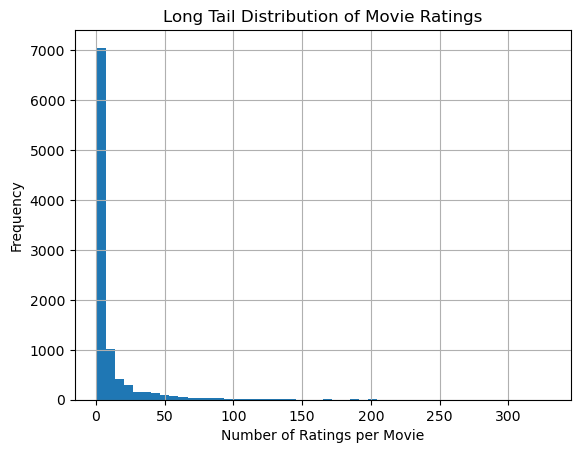

In [13]:
movie_rating_counts = ratings.groupby('movieId').size()

movie_rating_counts.hist(bins=50)

plt.title("Long Tail Distribution of Movie Ratings")
plt.xlabel("Number of Ratings per Movie")
plt.ylabel("Frequency")

plt.show()

In [14]:
print("Recommendations for User 1:")

recommend_movie_titles(1)

Recommendations for User 1:


,title
4604,Ninja Scroll (Jûbei ninpûchô) (1995)
4908,Dawn of the Dead (2004)
4927,Dawn of the Dead (1978)
5260,Spider-Man 2 (2004)
5335,Shaun of the Dead (2004)
